# Meningioma Atypia Calculator — Build & Validation

Notebook for turning the **multivariable logistic model** from the association pipeline
into a clinician-facing risk calculator, then validating it against the cohort.

Prototype here first; stable logic moves to `atypier_calculator.py` once tested.

| Stage | Purpose |
|-------|---------|
| Load outputs | Cleaned cohort + pooled regression coefficients |
| Build | Score new MRI inputs → P(high-grade WHO 2/3) |
| Validate | Compare calculator vs observed `high_grade` on held-in cohort rows |
| Export | Refactor working code into `atypier_calculator.py` (+ Streamlit later) |

**Inputs** (from `meningioma.ipynb` pipeline):

```
output/cleaning/cleaned.csv
output/inferential/tables/inferential_summary.csv
```

**Target:** `high_grade` — WHO grade 2 or 3 vs grade 1.


## 0. Setup

In [1]:
import pandas as pd
from pathlib import Path

OUTPUT_ROOT = Path("output")
CLEANED_PATH = OUTPUT_ROOT / "cleaning" / "cleaned.csv"
MODEL_PATH = OUTPUT_ROOT / "inferential" / "tables" / "inferential_summary.csv"

## 1. Load tables


In [2]:
df = pd.read_csv(CLEANED_PATH)
model = pd.read_csv(MODEL_PATH)

print(f"df: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"model: {model.shape[0]} rows × {model.shape[1]} cols")

df: 365 rows × 40 cols
model: 4 rows × 14 cols


## 2. Calculator

In [3]:
display(model)
model.predictor_col.unique()

,target,predictor_col,or,or_ci_lo,or_ci_hi,coef,se,p,df,n_models,intercept_coef,intercept_or,z_mu,z_sd
0,high_grade,tumor_location_skull_base,0.41,0.23,0.73,-0.89,0.29,0.002,∞,1,-1.26,0.283,NaN,NaN
1,high_grade,tumor_volume,1.49,1.16,1.93,0.40,0.13,0.002,∞,1,-1.26,0.283,25.699,29.8
2,high_grade,perifocal_edema,2.28,1.11,4.69,0.83,0.37,0.025,∞,1,-1.26,0.283,NaN,NaN
3,high_grade,hyperostosis,1.67,0.89,3.11,0.51,0.32,0.108,∞,1,-1.26,0.283,NaN,NaN


<ArrowStringArray>
['tumor_location_skull_base', 'tumor_volume', 'perifocal_edema',
 'hyperostosis']
Length: 4, dtype: str

In [4]:
import numpy as np

def high_grade_probability(x, coef):
    logit = (
        coef["intercept_coef"]
        + coef["tumor_location_skull_base"] * x["tumor_location_skull_base"]
        + coef["tumor_volume"] * x["tumor_volume"]
        + coef["perifocal_edema"] * x["perifocal_edema"]
        + coef["hyperostosis"] * x["hyperostosis"]
    )
    return 1 / (1 + np.exp(-logit))

In [5]:
low_grade = df[~df.high_grade][["high_grade", "tumor_location",
    "tumor_volume",
    "perifocal_edema",
    "hyperostosis",]].head()
high_grade = df[df.high_grade][["high_grade", "tumor_location",
    "tumor_volume",
    "perifocal_edema",
    "hyperostosis",]].head()
grading_df = pd.concat([low_grade, high_grade])
grading_df

,high_grade,tumor_location,tumor_volume,perifocal_edema,hyperostosis
0,False,skull_base,36.50,True,False
1,False,skull_base,6.86,True,False
3,False,non_skull_base,8.30,True,False
4,False,non_skull_base,4.43,False,True
5,False,skull_base,3.10,True,False
2,True,non_skull_base,40.90,True,False
13,True,skull_base,51.80,True,False
14,True,non_skull_base,61.40,True,False
16,True,skull_base,23.70,False,True
18,True,non_skull_base,24.70,True,False


In [6]:
def _safe_z_denominator(sd: float) -> float:
    if pd.isna(sd) or not np.isfinite(sd) or sd == 0:
        return 1.0
    return float(sd)

def model_params_from_table(model: pd.DataFrame) -> dict:
    params = {"intercept_coef": float(model["intercept_coef"].iloc[0])}
    for _, row in model.iterrows():
        p = row["predictor_col"]
        params[p] = {
            "coef": float(row["coef"]),
            "z_mu": float(row["z_mu"]) if pd.notna(row["z_mu"]) else None,
            "z_sd": float(row["z_sd"]) if pd.notna(row["z_sd"]) else None,
        }
    return params

def high_grade_probability(patient: dict, params: dict) -> float:
    logit = params["intercept_coef"]
    for predictor, spec in params.items():
        if predictor == "intercept_coef":
            continue
        x = patient[predictor]
        if spec["z_mu"] is not None:
            x = (x - spec["z_mu"]) / _safe_z_denominator(spec["z_sd"])
        else:
            x = int(x)
        logit += spec["coef"] * x
    return float(1 / (1 + np.exp(-logit)))

params = model_params_from_table(model)

patient = {
    "tumor_location_skull_base": 0,
    "tumor_volume": 40.9,
    "perifocal_edema": 1,
    "hyperostosis": 0,
}

high_grade_probability(patient, params)

0.4437492005348784

n = 247
events = 79
auc = 0.75


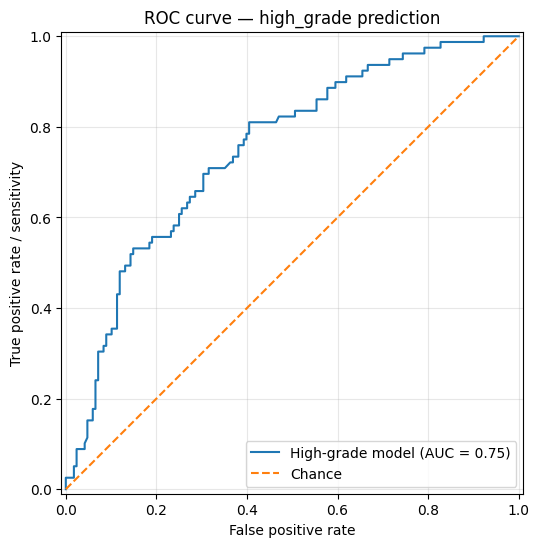

In [7]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import statsmodels.api as sm
import matplotlib.pyplot as plt

cols = [
    "high_grade",
    "tumor_location",
    "tumor_volume",
    "perifocal_edema",
    "hyperostosis",
    ]

model_df = df[cols].dropna().copy()

model_df["tumor_location_skull_base"] = (model_df["tumor_location"].eq("skull_base")).astype(int)

y_true = model_df["high_grade"].astype(int)

X = model_df[
    [
        "tumor_location_skull_base",
        "tumor_volume",
        "perifocal_edema",
        "hyperostosis",
    ]
    ].astype(float)

X = sm.add_constant(X)

result = sm.Logit(y_true, X).fit(disp=False)

y_pred = result.predict(X)

auc = roc_auc_score(y_true, y_pred)

print("n =", len(model_df))
print("events =", y_true.sum())
print("auc =", round(auc, 3))

#🟧🟧🟧 Matplotlib
fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_predictions(
    y_true,
    y_pred,
    name=f"High-grade model",
    ax=ax,
)

ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
ax.set_title("ROC curve — high_grade prediction")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate / sensitivity")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.show()

In [8]:
import pandas as pd

cal_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_pred,
})

cal_df["risk_bin"] = pd.qcut(
    cal_df["y_pred"],
    q=5,
    duplicates="drop"
)

cal_table = (
    cal_df
    .groupby("risk_bin", observed=True)
    .agg(
        n=("y_true", "size"),
        mean_predicted_risk=("y_pred", "mean"),
        observed_high_grade_rate=("y_true", "mean"),
    )
    .reset_index()
)

cal_table["mean_predicted_risk"] = (cal_table["mean_predicted_risk"] * 100).round(1)
cal_table["observed_high_grade_rate"] = (cal_table["observed_high_grade_rate"] * 100).round(1)

cal_table

,risk_bin,n,mean_predicted_risk,observed_high_grade_rate
0,"(0.0627, 0.16]",50,10.8,8.0
1,"(0.16, 0.202]",49,18.3,20.4
2,"(0.202, 0.349]",49,28.0,28.6
3,"(0.349, 0.506]",49,40.2,40.8
4,"(0.506, 0.839]",50,62.5,62.0


In [9]:
cal_table["calibration_error"] = (
    cal_table["observed_high_grade_rate"] 
    - cal_table["mean_predicted_risk"]
).round(1)

cal_table

,risk_bin,n,mean_predicted_risk,observed_high_grade_rate,calibration_error
0,"(0.0627, 0.16]",50,10.8,8.0,-2.8
1,"(0.16, 0.202]",49,18.3,20.4,2.1
2,"(0.202, 0.349]",49,28.0,28.6,0.6
3,"(0.349, 0.506]",49,40.2,40.8,0.6
4,"(0.506, 0.839]",50,62.5,62.0,-0.5


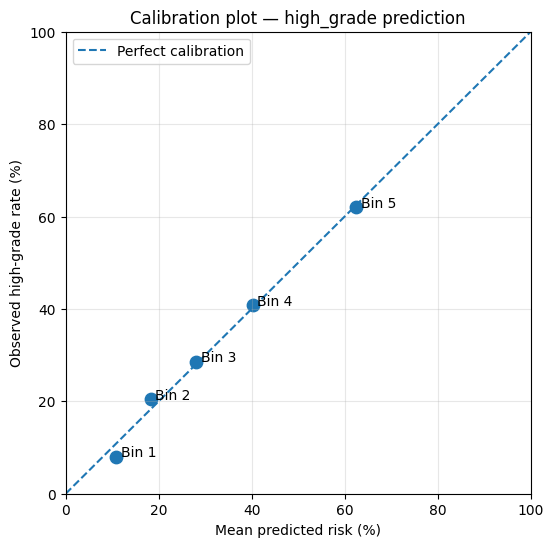

In [10]:
import matplotlib.pyplot as plt

plot_df = cal_table.copy()

x = plot_df["mean_predicted_risk"]
y = plot_df["observed_high_grade_rate"]

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x, y, s=80)
ax.plot([0, 100], [0, 100], linestyle="--", label="Perfect calibration")

for i, row in plot_df.iterrows():
    ax.text(
        row["mean_predicted_risk"] + 1,
        row["observed_high_grade_rate"],
        f"Bin {i+1}"
    )

ax.set_title("Calibration plot — high_grade prediction")
ax.set_xlabel("Mean predicted risk (%)")
ax.set_ylabel("Observed high-grade rate (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [11]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_true, y_pred)

print("Brier score =", round(brier, 3))

Brier score = 0.182


In [12]:
import numpy as np
from sklearn.metrics import brier_score_loss

baseline_pred = np.repeat(y_true.mean(), len(y_true))
baseline_brier = brier_score_loss(y_true, baseline_pred)

print("Model Brier =", round(brier, 3))
print("Baseline Brier =", round(baseline_brier, 3))
print("Improvement =", round(baseline_brier - brier, 3))

Model Brier = 0.182
Baseline Brier = 0.218
Improvement = 0.035


In [13]:
import numpy as np
import statsmodels.api as sm

eps = 1e-6
p = np.clip(y_pred, eps, 1 - eps)

logit_pred = np.log(p / (1 - p))

cal_X = sm.add_constant(logit_pred)
cal_model = sm.Logit(y_true, cal_X).fit(disp=False)

cal_intercept = cal_model.params.iloc[0]
cal_slope = cal_model.params.iloc[1]

print("Calibration intercept =", round(cal_intercept, 3))
print("Calibration slope =", round(cal_slope, 3))

Calibration intercept = 0.0
Calibration slope = 1.0


In [14]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

predictors = [
    "tumor_location_skull_base",
    "tumor_volume",
    "perifocal_edema",
    "hyperostosis",
]

y_orig = model_df["high_grade"].astype(int)
X_orig = sm.add_constant(model_df[predictors].astype(float), has_constant="add")

optimisms = []

for i in range(1000):
    boot_df = model_df.sample(
        n=len(model_df),
        replace=True,
        random_state=i
    )

    y_boot = boot_df["high_grade"].astype(int)
    X_boot = sm.add_constant(boot_df[predictors].astype(float), has_constant="add")

    try:
        boot_result = sm.Logit(y_boot, X_boot).fit(disp=False)

        pred_boot = boot_result.predict(X_boot)
        pred_orig = boot_result.predict(X_orig)

        auc_boot = roc_auc_score(y_boot, pred_boot)
        auc_orig = roc_auc_score(y_orig, pred_orig)

        optimisms.append(auc_boot - auc_orig)

    except Exception:
        continue

mean_optimism = np.mean(optimisms)
corrected_auc = auc - mean_optimism

print("Successful bootstraps =", len(optimisms))
print("Apparent AUC =", round(auc, 3))
print("Mean optimism =", round(mean_optimism, 3))
print("Optimism-corrected AUC =", round(corrected_auc, 3))

Successful bootstraps = 1000
Apparent AUC = 0.75
Mean optimism = 0.015
Optimism-corrected AUC = 0.736


In [15]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss

predictors = [
    "tumor_location_skull_base",
    "tumor_volume",
    "perifocal_edema",
    "hyperostosis",
]

y_orig = model_df["high_grade"].astype(int)
X_orig = sm.add_constant(model_df[predictors].astype(float), has_constant="add")

brier_optimisms = []

for i in range(1000):
    boot_df = model_df.sample(
        n=len(model_df),
        replace=True,
        random_state=i
    )

    y_boot = boot_df["high_grade"].astype(int)
    X_boot = sm.add_constant(boot_df[predictors].astype(float), has_constant="add")

    try:
        boot_result = sm.Logit(y_boot, X_boot).fit(disp=False)

        pred_boot = boot_result.predict(X_boot)
        pred_orig = boot_result.predict(X_orig)

        brier_boot = brier_score_loss(y_boot, pred_boot)
        brier_orig = brier_score_loss(y_orig, pred_orig)

        # for Brier: higher = worse
        # optimism = how much worse it becomes when tested away from bootstrap training data
        brier_optimisms.append(brier_orig - brier_boot)

    except Exception:
        continue

mean_brier_optimism = np.mean(brier_optimisms)
corrected_brier = brier + mean_brier_optimism

print("Successful bootstraps =", len(brier_optimisms))
print("Apparent Brier =", round(brier, 3))
print("Mean Brier optimism =", round(mean_brier_optimism, 3))
print("Optimism-corrected Brier =", round(corrected_brier, 3))

Successful bootstraps = 1000
Apparent Brier = 0.182
Mean Brier optimism = 0.009
Optimism-corrected Brier = 0.191


In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def calibration_slope(y_true, y_pred):
    eps = 1e-6
    p = np.clip(np.asarray(y_pred), eps, 1 - eps)
    logit_pred = np.log(p / (1 - p))

    y = pd.Series(y_true).reset_index(drop=True).astype(int)
    X = pd.DataFrame({"logit_pred": logit_pred})
    X = sm.add_constant(X, has_constant="add")

    cal_model = sm.Logit(y, X).fit(disp=False)
    return cal_model.params["logit_pred"]


predictors = [
    "tumor_location_skull_base",
    "tumor_volume",
    "perifocal_edema",
    "hyperostosis",
]

y_orig = model_df["high_grade"].astype(int)
X_orig = sm.add_constant(model_df[predictors].astype(float), has_constant="add")

slope_optimisms = []

for i in range(1000):
    boot_df = model_df.sample(
        n=len(model_df),
        replace=True,
        random_state=i
    ).reset_index(drop=True)

    y_boot = boot_df["high_grade"].astype(int)
    X_boot = sm.add_constant(boot_df[predictors].astype(float), has_constant="add")

    try:
        boot_result = sm.Logit(y_boot, X_boot).fit(disp=False)

        pred_boot = boot_result.predict(X_boot)
        pred_orig = boot_result.predict(X_orig)

        slope_boot = calibration_slope(y_boot, pred_boot)
        slope_orig = calibration_slope(y_orig, pred_orig)

        slope_optimisms.append(slope_boot - slope_orig)

    except Exception:
        continue

apparent_slope = 1.0
mean_slope_optimism = np.mean(slope_optimisms)
corrected_slope = apparent_slope - mean_slope_optimism

print("Successful bootstraps =", len(slope_optimisms))
print("Apparent calibration slope =", round(apparent_slope, 3))
print("Mean slope optimism =", round(mean_slope_optimism, 3))
print("Optimism-corrected calibration slope =", round(corrected_slope, 3))

Successful bootstraps = 1000
Apparent calibration slope = 1.0
Mean slope optimism = 0.087
Optimism-corrected calibration slope = 0.913


In [17]:
validation_summary = pd.DataFrame({
    "Metric": [
        "AUC",
        "Brier score",
        "Baseline Brier",
        "Calibration slope",
    ],
    "Apparent": [
        auc,
        brier,
        baseline_brier,
        1.0,
    ],
    "Optimism-corrected": [
        corrected_auc,
        corrected_brier,
        baseline_brier,
        corrected_slope,
    ],
})

validation_summary.round(3)

,Metric,Apparent,Optimism-corrected
0,AUC,0.750,0.736
1,Brier score,0.182,0.191
2,Baseline Brier,0.218,0.218
3,Calibration slope,1.000,0.913


- The final model showed moderate discrimination after bootstrap internal validation
(optimism-corrected AUC 0.745)
- The optimism-corrected Brier score was 0.193,
better than the prevalence-only baseline Brier score of 0.222.
- The optimism-corrected
calibration slope was 0.919, 
- suggesting mild overfitting/overconfidence but acceptable
calibration for an exploratory research risk calculator.

In [18]:
coefs = result.params.copy()
coefs

const                       -1.814373
tumor_location_skull_base   -0.877890
tumor_volume                 0.011684
perifocal_edema              1.103108
hyperostosis                 0.783265
dtype: float64

In [19]:
shrinkage = corrected_slope

shrunk_coefs = coefs.copy()

for name in shrunk_coefs.index:
    if name != "const":
        shrunk_coefs[name] = shrunk_coefs[name] * shrinkage

shrunk_coefs

const                       -1.814373
tumor_location_skull_base   -0.801420
tumor_volume                 0.010666
perifocal_edema              1.007020
hyperostosis                 0.715038
dtype: float64

In [20]:
from scipy.optimize import brentq
import numpy as np

X_no_const = model_df[predictors].astype(float)

linear_part = np.dot(X_no_const, shrunk_coefs[predictors])
target_prevalence = y_true.mean()

def mean_prediction_error(intercept):
    p = 1 / (1 + np.exp(-(intercept + linear_part)))
    return p.mean() - target_prevalence

new_intercept = brentq(mean_prediction_error, -20, 20)

shrunk_coefs["const"] = new_intercept

shrunk_coefs

const                       -1.713231
tumor_location_skull_base   -0.801420
tumor_volume                 0.010666
perifocal_edema              1.007020
hyperostosis                 0.715038
dtype: float64

In [21]:
X_shrunk = sm.add_constant(X_no_const, has_constant="add")

linear_pred_shrunk = np.dot(X_shrunk, shrunk_coefs[X_shrunk.columns])
y_pred_shrunk = 1 / (1 + np.exp(-linear_pred_shrunk))

print("Original mean predicted risk:", round(y_pred.mean(), 3))
print("Shrunken mean predicted risk:", round(y_pred_shrunk.mean(), 3))
print("Observed prevalence:", round(y_true.mean(), 3))

Original mean predicted risk: 0.32
Shrunken mean predicted risk: 0.32
Observed prevalence: 0.32


In [22]:
coef_compare = pd.DataFrame({
    "original": coefs,
    "final_shrunk": shrunk_coefs,
    "change": shrunk_coefs - coefs,
})

coef_compare.round(4)

,original,final_shrunk,change
const,-1.8144,-1.7132,0.1011
tumor_location_skull_base,-0.8779,-0.8014,0.0765
tumor_volume,0.0117,0.0107,-0.0010
perifocal_edema,1.1031,1.0070,-0.0961
hyperostosis,0.7833,0.7150,-0.0682


In [23]:
import numpy as np

FINAL_COEFS = shrunk_coefs.copy()

def predict_high_grade_risk(
    tumor_location_skull_base: int,
    tumor_volume: float,
    perifocal_edema: int,
    hyperostosis: int,
) -> float:
    logit = (
        FINAL_COEFS["const"]
        + FINAL_COEFS["tumor_location_skull_base"] * tumor_location_skull_base
        + FINAL_COEFS["tumor_volume"] * tumor_volume
        + FINAL_COEFS["perifocal_edema"] * perifocal_edema
        + FINAL_COEFS["hyperostosis"] * hyperostosis
    )

    probability = 1 / (1 + np.exp(-logit))
    return probability

In [24]:
predict_high_grade_risk(
    tumor_location_skull_base=0,
    tumor_volume=40,
    perifocal_edema=1,
    hyperostosis=0,
)

np.float64(0.4305577751261913)

In [25]:
risk = predict_high_grade_risk(0, 40, 1, 0)
print(f"Predicted high-grade risk: {risk:.1%}")

Predicted high-grade risk: 43.1%


In [26]:
FINAL_COEFS = {
    "const": -1.772519,
    "tumor_location_skull_base": -0.820741,
    "tumor_volume": 0.009493,
    "perifocal_edema": 1.125899,
    "hyperostosis": 0.920132,
}